# Lab 04 — Regression Using PyTorch

**Objective:** Implement polynomial (quadratic) regression using PyTorch's `nn.Module` API.  
The model learns parameters for the function **ŷ = w·x + b + x²** from a CSV dataset.

In [4]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd

In [5]:
df = pd.read_csv('assignment-data.csv')

In [6]:
df.head()

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


In [7]:
X = torch.tensor(df['x'].values, dtype=torch.float32)
y = torch.tensor(df['y'].values, dtype=torch.float32)
print(f"X-Shape: {X.shape}")
print(f"y-Shape: {y.shape}")

X-Shape: torch.Size([50])
y-Shape: torch.Size([50])


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([35]), torch.Size([35]), torch.Size([15]), torch.Size([15]))

# **Plotting the nature of training and testing set**

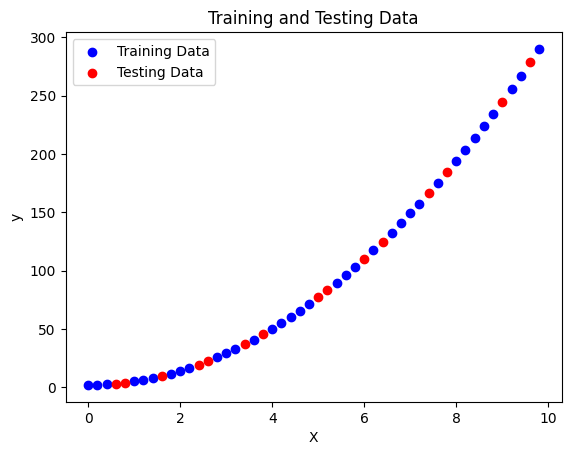

In [11]:
plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.scatter(X_test, y_test, label='Testing Data', color='red')
plt.title('Training and Testing Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [12]:
import torch.nn as nn

# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias + x**2 # <- Quadratic regression formula (y = wx + b + x^2)

In [13]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

In [14]:
print(model_0.weights)
print(model_0.bias)

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


In [15]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds[:5]

tensor([ 7.7642, 63.5950, 38.1490, 84.1590, 12.8336])

# **Plotting the predictions**

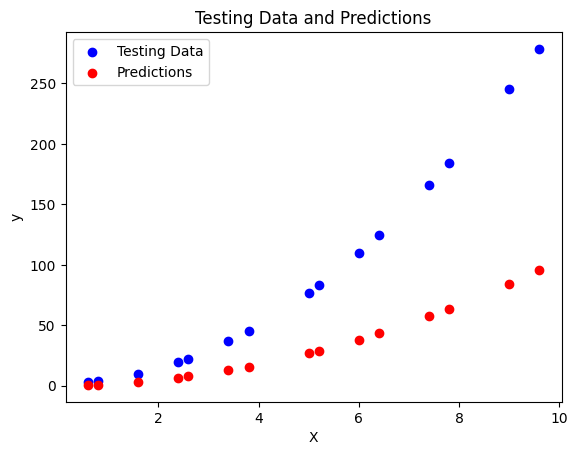

In [16]:
plt.scatter(X_test, y_test, label='Testing Data', color='blue')
plt.scatter(X_test, y_preds, label='Predictions', color='red')
plt.title('Testing Data and Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [17]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [18]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 2000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 66.3265609741211 | MAE Test Loss: 61.32957458496094 
Epoch: 10 | MAE Train Loss: 63.772071838378906 | MAE Test Loss: 58.86472702026367 
Epoch: 20 | MAE Train Loss: 61.21757125854492 | MAE Test Loss: 56.39987564086914 
Epoch: 30 | MAE Train Loss: 58.66307067871094 | MAE Test Loss: 53.93503952026367 
Epoch: 40 | MAE Train Loss: 56.10858154296875 | MAE Test Loss: 51.47018051147461 
Epoch: 50 | MAE Train Loss: 53.554080963134766 | MAE Test Loss: 49.00532913208008 
Epoch: 60 | MAE Train Loss: 51.00175476074219 | MAE Test Loss: 46.56752395629883 
Epoch: 70 | MAE Train Loss: 48.59150695800781 | MAE Test Loss: 44.29446792602539 
Epoch: 80 | MAE Train Loss: 46.304046630859375 | MAE Test Loss: 42.166236877441406 
Epoch: 90 | MAE Train Loss: 44.16213607788086 | MAE Test Loss: 40.12834930419922 
Epoch: 100 | MAE Train Loss: 42.16318130493164 | MAE Test Loss: 38.16026306152344 
Epoch: 110 | MAE Train Loss: 40.220008850097656 | MAE Test Loss: 36.395694732666016 
Epoch: 120

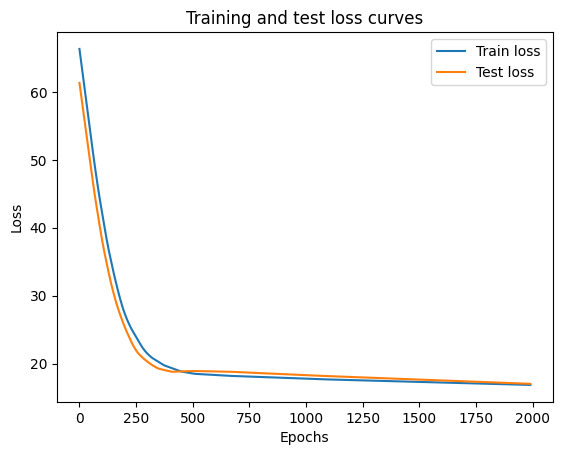

In [19]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [20]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([14.8062]), 'bias': tensor([-3.6349])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


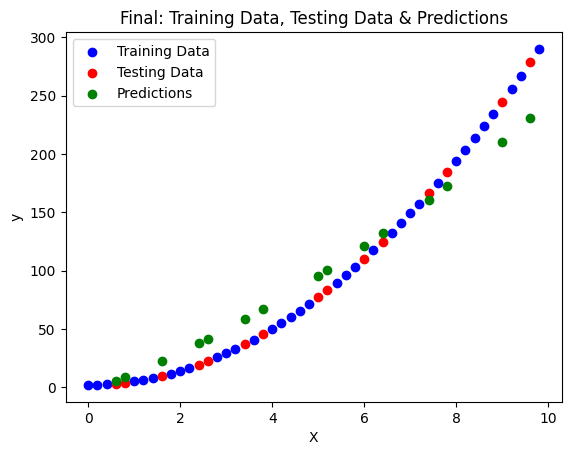

In [21]:
model_0.eval()

# Setup the inference mode context manager
with torch.inference_mode():
  y_preds = model_0(X_test)

plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.scatter(X_test, y_test, label='Testing Data', color='red')
plt.scatter(X_test, y_preds, label='Predictions', color='green')
plt.title('Final: Training Data, Testing Data & Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()